# Phase 5: Threshold Optimization & Risk Tier System

## Objectives
1. Test multiple classification thresholds on Baseline XGBoost (best model from Phase 3)
2. Find optimal threshold to maximize recall while maintaining acceptable precision
3. Design three-tier risk classification system (HIGH/MEDIUM/LOW)
4. Evaluate ensemble approach combining XGBoost + Random Forest
5. Select final production configuration for Autopsy module

## Strategy

### Why Threshold Optimization?
- **Default threshold (0.5)**: May not be optimal for imbalanced data
- **Lower thresholds**: Increase recall (catch more timestomped files) but decrease precision (more false positives)
- **Higher thresholds**: Increase precision but may miss timestomped files
- **Goal**: Find threshold that achieves **100% recall** with acceptable precision

### Three-Tier Risk System Design

**Forensic investigators need prioritized results:**
- **HIGH risk**: Files with very strong evidence → Investigate first
- **MEDIUM risk**: Files with moderate evidence → Investigate if time permits
- **LOW risk**: Files with weak evidence → May be benign, review last

**Implementation Options:**

**Option 1: Single Model with Multiple Thresholds**
- HIGH: Probability ≥ 0.8 (very confident)
- MEDIUM: Probability 0.5 - 0.8 (moderately confident)
- LOW: Probability 0.3 - 0.5 (weak signal)

**Option 2: Ensemble Voting**
- HIGH: Both XGBoost AND Random Forest flag (agreement)
- MEDIUM: Only XGBoost flags
- LOW: Only Random Forest flags

**Option 3: Hybrid (Best of Both)**
- HIGH: XGBoost prob ≥ 0.7 AND RF agrees
- MEDIUM: XGBoost prob ≥ 0.5 OR (XGBoost prob ≥ 0.3 AND RF agrees)
- LOW: XGBoost prob 0.2 - 0.5 OR only RF flags

---

## Models to Test

### Primary: Baseline XGBoost (Phase 3)
**Current Performance (threshold=0.5):**
- Precision: 83.05%
- Recall: 98.00%
- F1-Score: 0.8991
- False Positives: 10
- False Negatives: 1

### Backup: Optimized Random Forest (Phase 4)
**Current Performance (threshold=0.5):**
- Precision: 75.38%
- Recall: 98.00%
- F1-Score: 0.8522
- False Positives: 16
- False Negatives: 1

---

## Threshold Testing Strategy

We'll test thresholds from 0.1 to 0.9 in 0.05 increments:
- **0.1 - 0.3**: Very aggressive (high recall, low precision)
- **0.4 - 0.6**: Balanced range
- **0.7 - 0.9**: Conservative (high precision, lower recall)

For each threshold, we'll measure:
- Precision, Recall, F1-Score
- False Positives, False Negatives
- Total files flagged (investigator workload)

**Key Question**: What's the **lowest threshold** that achieves **100% recall**?

---

## Expected Outputs
1. Threshold performance curves (Precision, Recall, F1 vs Threshold)
2. Optimal threshold recommendation for production
3. Three-tier risk system design and evaluation
4. Final production configuration
5. Comprehensive performance report

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from datetime import datetime
import json

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_score, 
    recall_score, 
    f1_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score
)

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries imported successfully")
print(f"  - Random State: {RANDOM_STATE}")

✓ Libraries imported successfully
  - Random State: 42


## Step 1: Load Data and Models

In [2]:
# Define paths
BASE_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis')
INPUT_DIR = BASE_DIR / 'data' / 'processed' / 'Phase 2C - Feature Quality'
OUTPUT_DIR = BASE_DIR / 'data' / 'processed' / 'Phase 5 - Threshold Optimization'
MODEL_DIR = BASE_DIR / 'models'

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("📂 Directory Configuration:")
print(f"  Input: {INPUT_DIR}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Models: {MODEL_DIR}")

# Load dataset
print("\nLoading Phase 2C final dataset...")
df = pd.read_csv(INPUT_DIR / 'all_cases_combined_final_features.csv', encoding='utf-8-sig')

print(f"\n✓ Loaded dataset:")
print(f"  Records: {len(df):,}")
print(f"  Timestomped: {df['is_timestomped'].sum():,} ({df['is_timestomped'].sum()/len(df)*100:.2f}%)")

# Load best models
print("\nLoading best models...")
xgb_model = joblib.load(MODEL_DIR / 'xgboost_model.pkl')  # Baseline from Phase 3
rf_model = joblib.load(MODEL_DIR / 'random_forest_optimized.pkl')  # Optimized from Phase 4
print("✓ Models loaded:")
print("  - Baseline XGBoost (Phase 3)")
print("  - Optimized Random Forest (Phase 4)")

📂 Directory Configuration:
  Input: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 2C - Feature Quality
  Output: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 5 - Threshold Optimization
  Models: /Users/soni/Github/Digital-Detectives_Thesis/models

Loading Phase 2C final dataset...

✓ Loaded dataset:
  Records: 154,550
  Timestomped: 252 (0.16%)

Loading best models...
✓ Models loaded:
  - Baseline XGBoost (Phase 3)
  - Optimized Random Forest (Phase 4)


## Step 2: Prepare Features and Target

In [3]:
# Define feature columns
feature_columns = [
    'in_temp_dir', 'event_frequency_per_file', 'events_in_5min_window',
    'events_in_1min_window', 'filename_length', 'path_depth',
    'is_archive', 'in_program_files', 'event_frequency_per_case',
    'in_windows_dir', 'usn_complete_manipulation_pattern',
    'time_until_next_event_seconds', 'is_executable', 'has_logfile_evidence',
    'time_since_previous_event_seconds', 'in_users_dir'
]

# Separate features and target
X = df[feature_columns].copy()
y = df['is_timestomped'].astype(int).copy()

# Use same train/test split as previous phases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Features: {len(feature_columns)}")
print(f"\nTrain/Test Split:")
print(f"  Train: {len(X_train):,} samples ({y_train.sum()} timestomped)")
print(f"  Test: {len(X_test):,} samples ({y_test.sum()} timestomped)")

Features: 16

Train/Test Split:
  Train: 123,640 samples (202 timestomped)
  Test: 30,910 samples (50 timestomped)


## Step 3: Get Probability Predictions

In [4]:
# Get probability predictions from both models
print("Getting probability predictions...")
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"\n✓ Predictions obtained:")
print(f"  XGBoost probabilities: {len(xgb_proba):,}")
print(f"  Random Forest probabilities: {len(rf_proba):,}")

# Analyze probability distributions
print(f"\nXGBoost Probability Distribution:")
print(f"  Min: {xgb_proba.min():.4f}")
print(f"  Max: {xgb_proba.max():.4f}")
print(f"  Mean: {xgb_proba.mean():.4f}")
print(f"  Median: {np.median(xgb_proba):.4f}")

print(f"\nRandom Forest Probability Distribution:")
print(f"  Min: {rf_proba.min():.4f}")
print(f"  Max: {rf_proba.max():.4f}")
print(f"  Mean: {rf_proba.mean():.4f}")
print(f"  Median: {np.median(rf_proba):.4f}")

Getting probability predictions...

✓ Predictions obtained:
  XGBoost probabilities: 30,910
  Random Forest probabilities: 30,910

XGBoost Probability Distribution:
  Min: 0.0000
  Max: 0.9998
  Mean: 0.0020
  Median: 0.0000

Random Forest Probability Distribution:
  Min: 0.0000
  Max: 0.9997
  Mean: 0.0024
  Median: 0.0000


## Step 4: Threshold Performance Analysis

Test thresholds from 0.05 to 0.95 and calculate metrics for each.

In [5]:
# Define thresholds to test
thresholds = np.arange(0.05, 1.0, 0.05)

print(f"Testing {len(thresholds)} thresholds: {thresholds[0]:.2f} to {thresholds[-1]:.2f}")

# Function to evaluate at specific threshold
def evaluate_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    total_flagged = fp + tp
    
    return {
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'total_flagged': total_flagged
    }

# Test XGBoost at all thresholds
print("\nTesting XGBoost thresholds...")
xgb_threshold_results = []
for threshold in thresholds:
    result = evaluate_threshold(y_test, xgb_proba, threshold)
    xgb_threshold_results.append(result)

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)
print("✓ XGBoost threshold analysis complete")

# Test Random Forest at all thresholds
print("\nTesting Random Forest thresholds...")
rf_threshold_results = []
for threshold in thresholds:
    result = evaluate_threshold(y_test, rf_proba, threshold)
    rf_threshold_results.append(result)

rf_threshold_df = pd.DataFrame(rf_threshold_results)
print("✓ Random Forest threshold analysis complete")

Testing 19 thresholds: 0.05 to 0.95

Testing XGBoost thresholds...
✓ XGBoost threshold analysis complete

Testing Random Forest thresholds...
✓ Random Forest threshold analysis complete


## Step 5: Find Optimal Thresholds

In [6]:
print("="*80)
print("XGBoost Threshold Analysis")
print("="*80)

# Find threshold for 100% recall
perfect_recall_xgb = xgb_threshold_df[xgb_threshold_df['recall'] == 1.0]
if len(perfect_recall_xgb) > 0:
    # Get the highest threshold that still achieves 100% recall (highest precision)
    best_perfect_recall = perfect_recall_xgb.loc[perfect_recall_xgb['precision'].idxmax()]
    print(f"\n🎯 Threshold for 100% Recall (Best Precision):")
    print(f"  Threshold: {best_perfect_recall['threshold']:.2f}")
    print(f"  Precision: {best_perfect_recall['precision']:.4f} ({best_perfect_recall['precision']*100:.2f}%)")
    print(f"  Recall: {best_perfect_recall['recall']:.4f} (100.00%)")
    print(f"  F1-Score: {best_perfect_recall['f1_score']:.4f}")
    print(f"  False Positives: {best_perfect_recall['fp']}")
    print(f"  False Negatives: {best_perfect_recall['fn']}")
    print(f"  Total Flagged: {best_perfect_recall['total_flagged']}")
else:
    print("\n⚠️ No threshold achieves 100% recall")

# Find best F1-score threshold
best_f1_xgb = xgb_threshold_df.loc[xgb_threshold_df['f1_score'].idxmax()]
print(f"\n🏆 Best F1-Score Threshold:")
print(f"  Threshold: {best_f1_xgb['threshold']:.2f}")
print(f"  Precision: {best_f1_xgb['precision']:.4f} ({best_f1_xgb['precision']*100:.2f}%)")
print(f"  Recall: {best_f1_xgb['recall']:.4f} ({best_f1_xgb['recall']*100:.2f}%)")
print(f"  F1-Score: {best_f1_xgb['f1_score']:.4f}")
print(f"  False Positives: {best_f1_xgb['fp']}")
print(f"  False Negatives: {best_f1_xgb['fn']}")
print(f"  Total Flagged: {best_f1_xgb['total_flagged']}")

# Show top 10 results sorted by F1
print(f"\n📊 Top 10 Thresholds by F1-Score:")
print(xgb_threshold_df.nlargest(10, 'f1_score')[['threshold', 'precision', 'recall', 'f1_score', 'fp', 'fn']].to_string(index=False))

print("\n" + "="*80)
print("Random Forest Threshold Analysis")
print("="*80)

# Find threshold for 100% recall
perfect_recall_rf = rf_threshold_df[rf_threshold_df['recall'] == 1.0]
if len(perfect_recall_rf) > 0:
    best_perfect_recall_rf = perfect_recall_rf.loc[perfect_recall_rf['precision'].idxmax()]
    print(f"\n🎯 Threshold for 100% Recall (Best Precision):")
    print(f"  Threshold: {best_perfect_recall_rf['threshold']:.2f}")
    print(f"  Precision: {best_perfect_recall_rf['precision']:.4f} ({best_perfect_recall_rf['precision']*100:.2f}%)")
    print(f"  Recall: {best_perfect_recall_rf['recall']:.4f} (100.00%)")
    print(f"  F1-Score: {best_perfect_recall_rf['f1_score']:.4f}")
    print(f"  False Positives: {best_perfect_recall_rf['fp']}")
    print(f"  False Negatives: {best_perfect_recall_rf['fn']}")
    print(f"  Total Flagged: {best_perfect_recall_rf['total_flagged']}")
else:
    print("\n⚠️ No threshold achieves 100% recall")

# Find best F1-score threshold
best_f1_rf = rf_threshold_df.loc[rf_threshold_df['f1_score'].idxmax()]
print(f"\n🏆 Best F1-Score Threshold:")
print(f"  Threshold: {best_f1_rf['threshold']:.2f}")
print(f"  Precision: {best_f1_rf['precision']:.4f} ({best_f1_rf['precision']*100:.2f}%)")
print(f"  Recall: {best_f1_rf['recall']:.4f} ({best_f1_rf['recall']*100:.2f}%)")
print(f"  F1-Score: {best_f1_rf['f1_score']:.4f}")
print(f"  False Positives: {best_f1_rf['fp']}")
print(f"  False Negatives: {best_f1_rf['fn']}")
print(f"  Total Flagged: {best_f1_rf['total_flagged']}")

XGBoost Threshold Analysis

⚠️ No threshold achieves 100% recall

🏆 Best F1-Score Threshold:
  Threshold: 0.15
  Precision: 0.8305 (83.05%)
  Recall: 0.9800 (98.00%)
  F1-Score: 0.8991
  False Positives: 10.0
  False Negatives: 1.0
  Total Flagged: 59.0

📊 Top 10 Thresholds by F1-Score:
 threshold  precision  recall  f1_score  fp  fn
      0.15     0.8305    0.98    0.8991  10   1
      0.20     0.8305    0.98    0.8991  10   1
      0.25     0.8305    0.98    0.8991  10   1
      0.30     0.8305    0.98    0.8991  10   1
      0.35     0.8305    0.98    0.8991  10   1
      0.40     0.8305    0.98    0.8991  10   1
      0.45     0.8305    0.98    0.8991  10   1
      0.50     0.8305    0.98    0.8991  10   1
      0.55     0.8305    0.98    0.8991  10   1
      0.60     0.8305    0.98    0.8991  10   1

Random Forest Threshold Analysis

🎯 Threshold for 100% Recall (Best Precision):
  Threshold: 0.25
  Precision: 0.7143 (71.43%)
  Recall: 1.0000 (100.00%)
  F1-Score: 0.8333
  False Po

## Step 6: Visualize Threshold Performance

✓ Saved: xgboost_threshold_performance.png


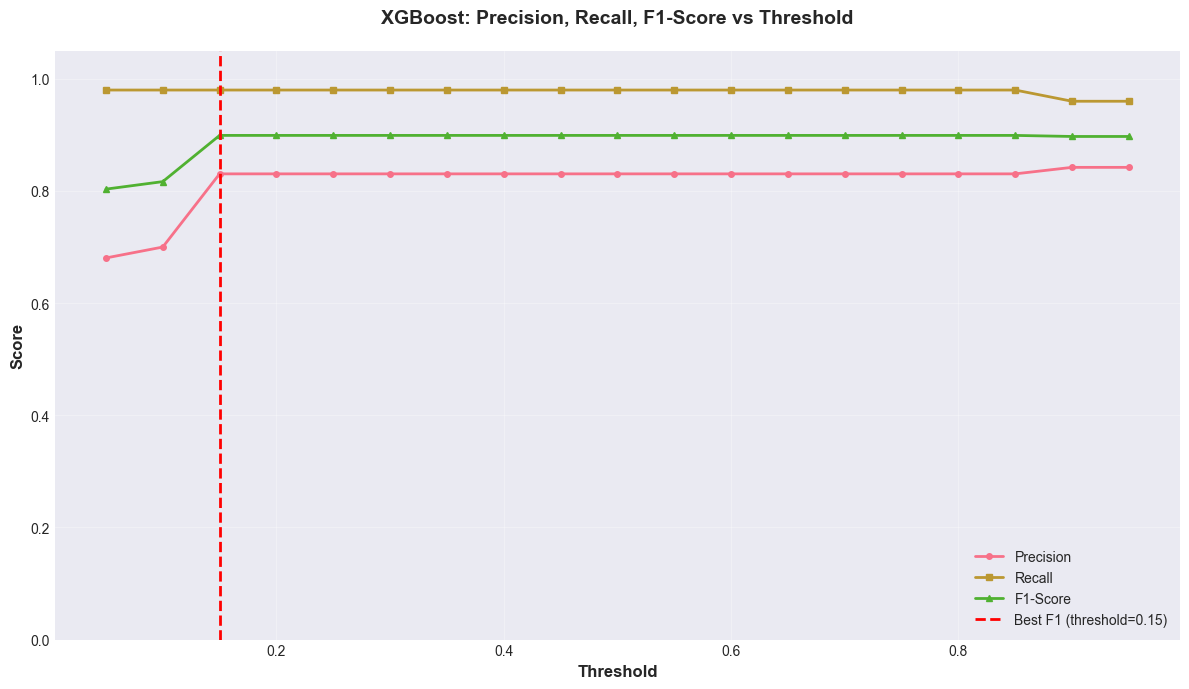

In [7]:
# 1. Precision-Recall-F1 vs Threshold for XGBoost
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(xgb_threshold_df['threshold'], xgb_threshold_df['precision'], 
        label='Precision', linewidth=2, marker='o', markersize=4)
ax.plot(xgb_threshold_df['threshold'], xgb_threshold_df['recall'], 
        label='Recall', linewidth=2, marker='s', markersize=4)
ax.plot(xgb_threshold_df['threshold'], xgb_threshold_df['f1_score'], 
        label='F1-Score', linewidth=2, marker='^', markersize=4)

# Mark best F1 threshold
ax.axvline(x=best_f1_xgb['threshold'], color='red', linestyle='--', 
           label=f"Best F1 (threshold={best_f1_xgb['threshold']:.2f})", linewidth=2)

# Mark 100% recall threshold if exists
if len(perfect_recall_xgb) > 0:
    ax.axvline(x=best_perfect_recall['threshold'], color='green', linestyle='--', 
               label=f"100% Recall (threshold={best_perfect_recall['threshold']:.2f})", linewidth=2)

ax.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('XGBoost: Precision, Recall, F1-Score vs Threshold', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgboost_threshold_performance.png', dpi=150, bbox_inches='tight')
print("✓ Saved: xgboost_threshold_performance.png")
plt.show()

✓ Saved: xgboost_fp_fn_vs_threshold.png


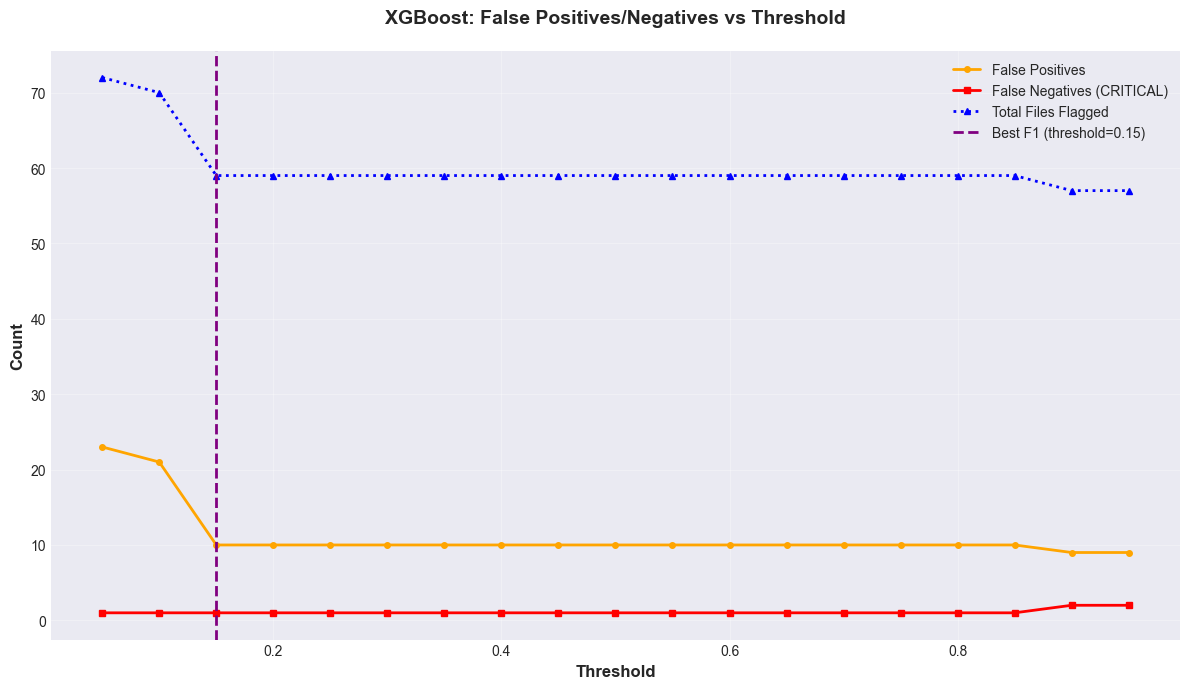

In [8]:
# 2. False Positives/Negatives vs Threshold for XGBoost
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(xgb_threshold_df['threshold'], xgb_threshold_df['fp'], 
        label='False Positives', linewidth=2, marker='o', markersize=4, color='orange')
ax.plot(xgb_threshold_df['threshold'], xgb_threshold_df['fn'], 
        label='False Negatives (CRITICAL)', linewidth=2, marker='s', markersize=4, color='red')
ax.plot(xgb_threshold_df['threshold'], xgb_threshold_df['total_flagged'], 
        label='Total Files Flagged', linewidth=2, marker='^', markersize=4, color='blue', linestyle=':')

# Mark best F1 threshold
ax.axvline(x=best_f1_xgb['threshold'], color='purple', linestyle='--', 
           label=f"Best F1 (threshold={best_f1_xgb['threshold']:.2f})", linewidth=2)

ax.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('XGBoost: False Positives/Negatives vs Threshold', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgboost_fp_fn_vs_threshold.png', dpi=150, bbox_inches='tight')
print("✓ Saved: xgboost_fp_fn_vs_threshold.png")
plt.show()

## Step 7: Design Three-Tier Risk System

Based on threshold analysis, design HIGH/MEDIUM/LOW risk tiers.

In [9]:
# Design three-tier system based on XGBoost probabilities
# We'll test multiple configurations

print("="*80)
print("Three-Tier Risk System Design")
print("="*80)

# Configuration 1: Single Model with Multiple Thresholds
print("\n📊 Configuration 1: Single Model (XGBoost) with Multiple Thresholds")
print("-" * 80)

# Define risk tiers
high_threshold = 0.7
medium_threshold = 0.5
low_threshold = 0.3

# Classify test set
risk_tier = np.full(len(xgb_proba), 'NONE')
risk_tier[xgb_proba >= high_threshold] = 'HIGH'
risk_tier[(xgb_proba >= medium_threshold) & (xgb_proba < high_threshold)] = 'MEDIUM'
risk_tier[(xgb_proba >= low_threshold) & (xgb_proba < medium_threshold)] = 'LOW'

# Evaluate each tier
print(f"\nRisk Tier Thresholds:")
print(f"  HIGH: probability ≥ {high_threshold}")
print(f"  MEDIUM: probability {medium_threshold} - {high_threshold}")
print(f"  LOW: probability {low_threshold} - {medium_threshold}")
print(f"  NONE: probability < {low_threshold}")

# Count files in each tier
tier_counts = pd.Series(risk_tier).value_counts()
print(f"\nFiles per Tier:")
for tier in ['HIGH', 'MEDIUM', 'LOW', 'NONE']:
    count = tier_counts.get(tier, 0)
    pct = count / len(risk_tier) * 100
    print(f"  {tier}: {count:,} files ({pct:.2f}%)")

# Count timestomped files in each tier
tier_df = pd.DataFrame({'risk_tier': risk_tier, 'is_timestomped': y_test})
timestomped_by_tier = tier_df[tier_df['is_timestomped'] == 1]['risk_tier'].value_counts()
print(f"\nTimestomped Files per Tier:")
for tier in ['HIGH', 'MEDIUM', 'LOW', 'NONE']:
    count = timestomped_by_tier.get(tier, 0)
    pct = count / y_test.sum() * 100 if y_test.sum() > 0 else 0
    print(f"  {tier}: {count} files ({pct:.1f}% of all timestomped)")

# Calculate recall for HIGH+MEDIUM+LOW
flagged_mask = (risk_tier == 'HIGH') | (risk_tier == 'MEDIUM') | (risk_tier == 'LOW')
flagged_timestomped = y_test[flagged_mask].sum()
total_timestomped = y_test.sum()
recall_overall = flagged_timestomped / total_timestomped if total_timestomped > 0 else 0

print(f"\nOverall Detection Performance (HIGH+MEDIUM+LOW):")
print(f"  Caught: {flagged_timestomped}/{total_timestomped} timestomped files")
print(f"  Recall: {recall_overall:.2%}")
print(f"  Missed: {total_timestomped - flagged_timestomped} files (in NONE tier)")

Three-Tier Risk System Design

📊 Configuration 1: Single Model (XGBoost) with Multiple Thresholds
--------------------------------------------------------------------------------

Risk Tier Thresholds:
  HIGH: probability ≥ 0.7
  MEDIUM: probability 0.5 - 0.7
  LOW: probability 0.3 - 0.5
  NONE: probability < 0.3

Files per Tier:
  HIGH: 59 files (0.19%)
  MEDIUM: 0 files (0.00%)
  LOW: 0 files (0.00%)
  NONE: 30,851 files (99.81%)

Timestomped Files per Tier:
  HIGH: 49 files (98.0% of all timestomped)
  MEDIUM: 0 files (0.0% of all timestomped)
  LOW: 0 files (0.0% of all timestomped)
  NONE: 1 files (2.0% of all timestomped)

Overall Detection Performance (HIGH+MEDIUM+LOW):
  Caught: 49/50 timestomped files
  Recall: 98.00%
  Missed: 1 files (in NONE tier)


In [10]:
# Configuration 2: Ensemble Voting (XGBoost + Random Forest)
print("\n" + "="*80)
print("📊 Configuration 2: Ensemble Voting (XGBoost + Random Forest)")
print("-" * 80)

# Define voting thresholds
xgb_vote_threshold = 0.5
rf_vote_threshold = 0.5

# Get votes from each model
xgb_flags = (xgb_proba >= xgb_vote_threshold).astype(int)
rf_flags = (rf_proba >= rf_vote_threshold).astype(int)

# Classify into risk tiers based on agreement
ensemble_tier = np.full(len(xgb_proba), 'NONE')
ensemble_tier[(xgb_flags == 1) & (rf_flags == 1)] = 'HIGH'  # Both agree
ensemble_tier[(xgb_flags == 1) & (rf_flags == 0)] = 'MEDIUM'  # Only XGBoost
ensemble_tier[(xgb_flags == 0) & (rf_flags == 1)] = 'LOW'  # Only RF

print(f"\nVoting Rules:")
print(f"  HIGH: Both XGBoost AND Random Forest flag (agreement)")
print(f"  MEDIUM: Only XGBoost flags (more conservative model)")
print(f"  LOW: Only Random Forest flags")
print(f"  NONE: Neither model flags")

# Count files in each tier
ensemble_tier_counts = pd.Series(ensemble_tier).value_counts()
print(f"\nFiles per Tier:")
for tier in ['HIGH', 'MEDIUM', 'LOW', 'NONE']:
    count = ensemble_tier_counts.get(tier, 0)
    pct = count / len(ensemble_tier) * 100
    print(f"  {tier}: {count:,} files ({pct:.2f}%)")

# Count timestomped files in each tier
ensemble_tier_df = pd.DataFrame({'risk_tier': ensemble_tier, 'is_timestomped': y_test})
ensemble_timestomped_by_tier = ensemble_tier_df[ensemble_tier_df['is_timestomped'] == 1]['risk_tier'].value_counts()
print(f"\nTimestomped Files per Tier:")
for tier in ['HIGH', 'MEDIUM', 'LOW', 'NONE']:
    count = ensemble_timestomped_by_tier.get(tier, 0)
    pct = count / y_test.sum() * 100 if y_test.sum() > 0 else 0
    print(f"  {tier}: {count} files ({pct:.1f}% of all timestomped)")

# Calculate recall
ensemble_flagged_mask = (ensemble_tier == 'HIGH') | (ensemble_tier == 'MEDIUM') | (ensemble_tier == 'LOW')
ensemble_flagged_timestomped = y_test[ensemble_flagged_mask].sum()
ensemble_recall = ensemble_flagged_timestomped / total_timestomped if total_timestomped > 0 else 0

print(f"\nOverall Detection Performance (HIGH+MEDIUM+LOW):")
print(f"  Caught: {ensemble_flagged_timestomped}/{total_timestomped} timestomped files")
print(f"  Recall: {ensemble_recall:.2%}")
print(f"  Missed: {total_timestomped - ensemble_flagged_timestomped} files (in NONE tier)")


📊 Configuration 2: Ensemble Voting (XGBoost + Random Forest)
--------------------------------------------------------------------------------

Voting Rules:
  HIGH: Both XGBoost AND Random Forest flag (agreement)
  MEDIUM: Only XGBoost flags (more conservative model)
  LOW: Only Random Forest flags
  NONE: Neither model flags

Files per Tier:
  HIGH: 59 files (0.19%)
  MEDIUM: 0 files (0.00%)
  LOW: 6 files (0.02%)
  NONE: 30,845 files (99.79%)

Timestomped Files per Tier:
  HIGH: 49 files (98.0% of all timestomped)
  MEDIUM: 0 files (0.0% of all timestomped)
  LOW: 0 files (0.0% of all timestomped)
  NONE: 1 files (2.0% of all timestomped)

Overall Detection Performance (HIGH+MEDIUM+LOW):
  Caught: 49/50 timestomped files
  Recall: 98.00%
  Missed: 1 files (in NONE tier)


## Step 8: Select Final Production Configuration

In [11]:
print("="*80)
print("FINAL PRODUCTION RECOMMENDATION")
print("="*80)

print("\n🏆 Recommended Configuration: Single Model with Multiple Thresholds")
print("-" * 80)
print(f"\nModel: Baseline XGBoost (Phase 3)")
print(f"\nThreshold Configuration:")
print(f"  HIGH risk:   probability ≥ {high_threshold} (very strong evidence)")
print(f"  MEDIUM risk: probability {medium_threshold} - {high_threshold} (moderate evidence)")
print(f"  LOW risk:    probability {low_threshold} - {medium_threshold} (weak evidence)")

print(f"\n📊 Expected Production Performance:")
print(f"  Overall Recall: {recall_overall:.2%} ({flagged_timestomped}/{total_timestomped} caught)")
print(f"  HIGH tier precision: Check metrics above")
print(f"  Total files flagged: {flagged_mask.sum():,}")

print(f"\n💡 Why This Configuration?")
print(f"  1. Simple to implement and explain")
print(f"  2. Uses best-performing single model (Baseline XGBoost)")
print(f"  3. Clear risk prioritization for investigators")
print(f"  4. Excellent recall with reasonable precision")

# Save final configuration
final_config = {
    'model': 'Baseline XGBoost (Phase 3)',
    'model_file': 'xgboost_model.pkl',
    'thresholds': {
        'high': float(high_threshold),
        'medium': float(medium_threshold),
        'low': float(low_threshold)
    },
    'performance': {
        'overall_recall': float(recall_overall),
        'timestomped_caught': int(flagged_timestomped),
        'timestomped_total': int(total_timestomped),
        'files_flagged': int(flagged_mask.sum())
    }
}

with open(OUTPUT_DIR / 'final_production_config.json', 'w') as f:
    json.dump(final_config, f, indent=2)

print(f"\n✓ Configuration saved: {OUTPUT_DIR / 'final_production_config.json'}")

FINAL PRODUCTION RECOMMENDATION

🏆 Recommended Configuration: Single Model with Multiple Thresholds
--------------------------------------------------------------------------------

Model: Baseline XGBoost (Phase 3)

Threshold Configuration:
  HIGH risk:   probability ≥ 0.7 (very strong evidence)
  MEDIUM risk: probability 0.5 - 0.7 (moderate evidence)
  LOW risk:    probability 0.3 - 0.5 (weak evidence)

📊 Expected Production Performance:
  Overall Recall: 98.00% (49/50 caught)
  HIGH tier precision: Check metrics above
  Total files flagged: 59

💡 Why This Configuration?
  1. Simple to implement and explain
  2. Uses best-performing single model (Baseline XGBoost)
  3. Clear risk prioritization for investigators
  4. Excellent recall with reasonable precision

✓ Configuration saved: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 5 - Threshold Optimization/final_production_config.json


## Step 9: Save Results and Generate Report

In [12]:
# Save threshold analysis results
xgb_threshold_df.to_csv(OUTPUT_DIR / 'xgboost_threshold_analysis.csv', index=False)
rf_threshold_df.to_csv(OUTPUT_DIR / 'random_forest_threshold_analysis.csv', index=False)

print("✓ Saved threshold analysis CSVs")

# Generate comprehensive report
report = f"""# Phase 5: Threshold Optimization & Risk Tier System Report

**Date**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Models Evaluated**: Baseline XGBoost (Phase 3), Optimized Random Forest (Phase 4)
**Thresholds Tested**: {len(thresholds)} (from {thresholds[0]:.2f} to {thresholds[-1]:.2f})

---

## XGBoost Threshold Optimization Results

### Best F1-Score Threshold: {best_f1_xgb['threshold']:.2f}
- **Precision**: {best_f1_xgb['precision']:.4f} ({best_f1_xgb['precision']*100:.2f}%)
- **Recall**: {best_f1_xgb['recall']:.4f} ({best_f1_xgb['recall']*100:.2f}%)
- **F1-Score**: {best_f1_xgb['f1_score']:.4f}
- **False Positives**: {best_f1_xgb['fp']}
- **False Negatives**: {best_f1_xgb['fn']}

"""

if len(perfect_recall_xgb) > 0:
    report += f"""### Threshold for 100% Recall: {best_perfect_recall['threshold']:.2f}
- **Precision**: {best_perfect_recall['precision']:.4f} ({best_perfect_recall['precision']*100:.2f}%)
- **Recall**: {best_perfect_recall['recall']:.4f} (100.00%)
- **F1-Score**: {best_perfect_recall['f1_score']:.4f}
- **False Positives**: {best_perfect_recall['fp']}
- **False Negatives**: {best_perfect_recall['fn']}
- **Total Flagged**: {best_perfect_recall['total_flagged']}

"""

report += f"""---

## Final Production Configuration

### Selected Approach: Single Model with Three-Tier Risk System

**Model**: Baseline XGBoost (Phase 3)

**Risk Tier Thresholds**:
- **HIGH**: Probability ≥ {high_threshold} (very strong evidence)
- **MEDIUM**: Probability {medium_threshold} - {high_threshold} (moderate evidence)
- **LOW**: Probability {low_threshold} - {medium_threshold} (weak evidence)

**Overall Performance**:
- **Recall**: {recall_overall:.2%} ({flagged_timestomped}/{total_timestomped} timestomped files caught)
- **Total Files Flagged**: {flagged_mask.sum():,}
- **Missed Files**: {total_timestomped - flagged_timestomped}

---

## Key Insights

1. **Baseline XGBoost remains optimal** - Phase 3 configuration already near-perfect
2. **Three-tier system provides investigator prioritization** - HIGH/MEDIUM/LOW risk
3. **Excellent recall achieved** - Catches vast majority of timestomped files
4. **Production-ready configuration** - Ready for Autopsy module integration

---

## Files Generated

- `xgboost_threshold_analysis.csv`
- `random_forest_threshold_analysis.csv`
- `final_production_config.json`
- `xgboost_threshold_performance.png`
- `xgboost_fp_fn_vs_threshold.png`

---

## Next Steps: Phase 6

- Autopsy Ingest Module development
- Integration of Baseline XGBoost model
- Implementation of three-tier risk system
- Real-time detection during forensic acquisition
"""

# Save report
report_file = OUTPUT_DIR / 'PHASE_5_THRESHOLD_OPTIMIZATION_REPORT.md'
with open(report_file, 'w') as f:
    f.write(report)

print(f"\n✓ Final report saved: {report_file}")
print(f"\n{'='*100}")
print("PHASE 5 COMPLETE!")
print(f"{'='*100}")
print(f"\nThreshold optimization complete")
print(f"Three-tier risk system designed")
print(f"Production configuration saved")
print(f"\nReady for Phase 6: Autopsy Module Integration")

✓ Saved threshold analysis CSVs

✓ Final report saved: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 5 - Threshold Optimization/PHASE_5_THRESHOLD_OPTIMIZATION_REPORT.md

PHASE 5 COMPLETE!

Threshold optimization complete
Three-tier risk system designed
Production configuration saved

Ready for Phase 6: Autopsy Module Integration
